# Part 1: Neural Network Fundamentals and Training Behavior Analysis

In [1]:
# Import all libraries

import pandas as pd                         
import numpy as np                           
import matplotlib.pyplot as plt              
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')                       

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# TensorFlow / Keras: for building the neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# To Make results reproducible 
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f' NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

All libraries imported successfully!
TensorFlow version: 2.21.0
 NumPy        : 2.4.2
Pandas       : 3.0.1


## Task 1: Dataset Understanding

In [2]:
# Loading the dataset 
df = pd.read_csv('customer_churn_nn.csv')

# Display first 5 rows of the dataset
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
rows, cols = df.shape #number of rows and columns 
print(f"Dataset has {rows} rows (customers) and {cols} columns (features + target)")
print("\nColumns:", df.columns.tolist())

Dataset has 2000 rows (customers) and 17 columns (features + target)

Columns: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


In [4]:
print("Column data types:")
print(df.dtypes)

print("\n--- Summary ---")
print(f"Categorical (text) columns: {list(df.select_dtypes('object').columns)}")
print(f"Numerical columns: {list(df.select_dtypes(['int64','float64']).columns)}")

Column data types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

--- Summary ---
Categorical (text) columns: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfac

In [10]:
# Missing value check 
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print('No missing values found in any column.')
else:
    print(missing[missing > 0])

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64
No missing values found in any column.


In [ ]:
# Statistical summary
print("Statistical Summary of Numerical Features:")
df.describe().round(2)

Statistical Summary of Numerical Features:


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


We have data about **2000 customers** of a telecom company.
We want to **predict**: Will a customer **leave (churn)** or **stay**?

- `churn = 1` → Customer left 
- `churn = 0` → Customer stayed 

In [13]:
#  Target Variable Description
churn_counts = df['churn'].value_counts()
print("Target variable distribution:")
print(churn_counts)
print(f"\nChurn rate: {df['churn'].mean()*100:.2f}%")

Target variable distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn rate: 1.55%


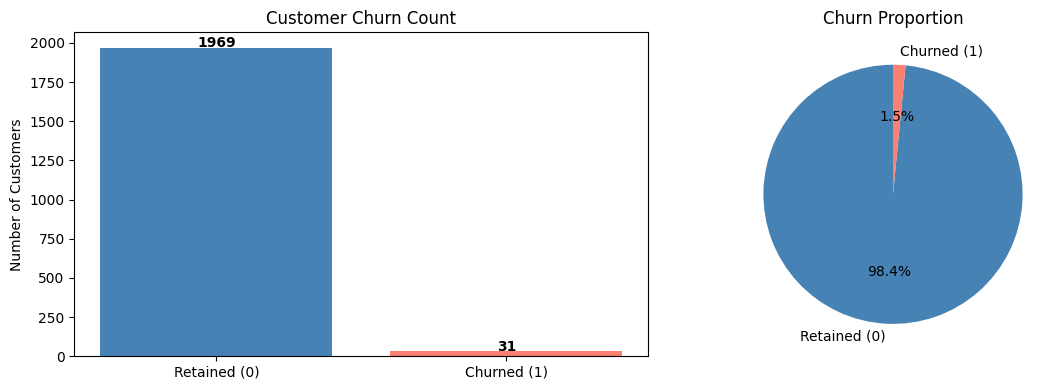

In [15]:
# Visualize the target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Customer Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.savefig('results/churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


OBSERVATION: The dataset is highly imbalanced. Only 1.5% customers have churned while 98.4% customers have been retained.

## TASK 2: Data Preprocessing

In [16]:
# Drop identifier column
df_clean = df.drop(columns=['customer_id'])

print(f"Columns before: {df.shape[1]}")
print(f"Columns after dropping customer_id: {df_clean.shape[1]}")
print(f"\nRemaining columns: {list(df_clean.columns)}")

Columns before: 17
Columns after dropping customer_id: 16

Remaining columns: ['region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


In [17]:
# Missing value handling 
# Confirmed no missing values in Task 1. If there were we would handle them by imputation or dropping colums or rows as apporiate.

In [18]:
# Identify categorical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

print("Unique values in each categorical column:")
for col in categorical_cols:
    print(f"  {col}: {df_clean[col].unique()}")

Unique values in each categorical column:
  region: <StringArray>
['South', 'West', 'Central', 'North', 'East']
Length: 5, dtype: str
  plan_type: <StringArray>
['Standard', 'Premium', 'Basic', 'Enterprise']
Length: 4, dtype: str
  contract_type: <StringArray>
['Month-to-month', 'One-year', 'Two-year']
Length: 3, dtype: str
  payment_method: <StringArray>
['Debit Card', 'Wallet', 'Credit Card', 'Net Banking', 'UPI']
Length: 5, dtype: str


In [19]:
# Encode categorical columns using One Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df_clean.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print(f"\nNew columns added by encoding:")
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(new_cols)
df_encoded.head(3)

Shape before encoding: (2000, 16)
Shape after encoding:  (2000, 25)

New columns added by encoding:
['region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False


In [20]:
# Define features(x) and Target (y)
# X = all input features (everything except churn)
# y = the target variable (churn)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

print(f"X (features) shape: {X.shape}  → {X.shape[0]} samples, {X.shape[1]} features")
print(f"y (target)   shape: {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

X (features) shape: (2000, 24)  → 2000 samples, 24 features
y (target)   shape: (2000,)

Feature names: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


In [21]:
# Feature Scaling — StandardScaler 
# Neural networks are sensitive to feature scale.
# Large-magnitude features (e.g. monthly_charges_inr ~600) would dominate small-magnitude features (e.g. referral_count ~1-2).
# StandardScaler → mean=0, std=1 per feature.

# Scale only numerical coloumns and not the one hot encoded columns (which are already 0/1)
numerical_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
                  'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
                  'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
                  'autopay_enabled', 'referral_count']

scaler = StandardScaler()

print("Before scaling (first 3 rows):")
print(X[numerical_cols].head(3).to_string())

Before scaling (first 3 rows):
   tenure_months  monthly_charges_inr  avg_login_days_per_month  support_tickets_last_90_days  payment_delay_days  data_usage_gb  satisfaction_score  last_complaint_days_ago  discount_percent  autopay_enabled  referral_count
0             30               687.40                        13                             0                   0          87.97                 8.0                       67                 0                0               0
1             15              1029.74                        22                             3                   1          82.17                 5.7                       69                 0                0               0
2             72               732.07                        13                             0                  11          89.39                 6.4                       63                10                0               0


In [22]:
# Train/Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # for reproducibility
    stratify=y          # keeps same churn ratio in both splits
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Testing set:   {X_test.shape[0]} rows")
print(f"\nChurn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.2f}%")

Training set:  1600 rows
Testing set:   400 rows

Churn rate in train: 1.56%
Churn rate in test:  1.50%


In [23]:
# Scaling numerical features (fit on training set, transform both train and test)
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test[numerical_cols])

print("After scaling (first 3 rows of training set):")
print(X_train_scaled[numerical_cols].head(3).round(3).to_string())

After scaling (first 3 rows of training set):
      tenure_months  monthly_charges_inr  avg_login_days_per_month  support_tickets_last_90_days  payment_delay_days  data_usage_gb  satisfaction_score  last_complaint_days_ago  discount_percent  autopay_enabled  referral_count
152          -0.040               -0.393                     0.905                         1.409              -0.649          0.422              -0.653                    0.405             1.551           -1.209           1.989
1540          0.674                0.296                     1.645                         0.720              -0.909          1.480              -1.380                   -0.052             1.551            0.827           1.033
154          -0.682                0.792                     1.460                         0.032               3.510          0.197               1.658                   -0.836            -1.094           -1.209           0.078


## Task 3: Neural Network Model Building

#### Build the model

In [ ]:
# Number of input features
n_features = X_train_scaled.shape[1]
print(f"Number of input features: {n_features}")

# Build the neural network using Keras Sequential API
model = keras.Sequential([
    layers.Input(shape=(n_features,)),  # Input layer
    layers.Dense(16, activation='relu'),  # Hidden layer 1
    layers.Dense(8, activation='relu'),   # Hidden layer 2
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',         # adjusts the weights
    loss='binary_crossentropy', # measures how wrong our predictions are
    metrics=['accuracy']         # tracks accuracy during training
)
# Print a summary of the model architecture
model.summary()


Number of input features: 24


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation

In [25]:
# Handle class imbalance

n_negative = (y_train == 0).sum()   # customers who didn't churn
n_positive = (y_train == 1).sum()   # customers who churned
ratio = n_negative / n_positive

print(f"Training set: {n_negative} non-churn, {n_positive} churn")
print(f"Class weight for churn=1: {ratio:.1f}x (it gets more attention)")

class_weights = {0: 1.0, 1: ratio}

#  Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,                   # number of times to go through all training data
    batch_size=32,               # process 32 samples at a time before updating weights
    validation_split=0.1,        # use 10% of training data for validation
    class_weight=class_weights,  # compensate for imbalance
    verbose=1                    # print progress
)

Training set: 1575 non-churn, 25 churn
Class weight for churn=1: 63.0x (it gets more attention)
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9417 - loss: 1.5026 - val_accuracy: 0.9125 - val_loss: 0.4109
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9069 - loss: 1.3771 - val_accuracy: 0.8562 - val_loss: 0.4329
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8736 - loss: 1.3028 - val_accuracy: 0.8125 - val_loss: 0.4425
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8535 - loss: 1.2493 - val_accuracy: 0.7812 - val_loss: 0.4417
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 1.2100 - val_accuracy: 0.7750 - val_loss: 0.4377
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - loss: 1.1748 - val_accuracy: 0.7688 - val_loss: 0.4338
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8319 - loss: 1.1388 - val_accuracy: 0.7625 - val_loss: 0.4292
Epoch 8/50
45/45 ━━━━━

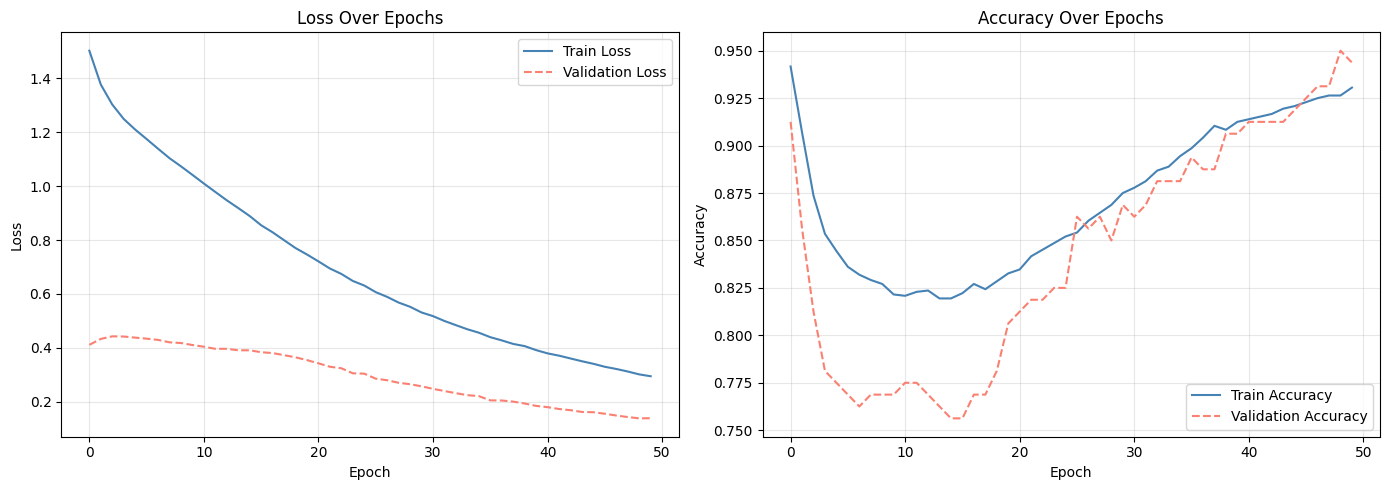

In [26]:
# Plot training History (loss and accuracy over epochs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Loss ──────────────────────────────────────────────────────
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='salmon',  linestyle='--')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Accuracy ──────────────────────────────────────────────────
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='salmon', linestyle='--')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_history.png', dpi=100, bbox_inches='tight')
plt.show()


Both loss curves going DOWN = model is learning

In [27]:
# Evaluate on Test Set
# Get predictions (probabilities between 0 and 1)
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to class labels (0 or 1) using threshold 0.5
# If probability > 0.5 → predict 1 (churn); else → predict 0 (no churn)
# Since we have imbalanced data lets keep threshold=0.3 to catch more churners
y_pred = (y_pred_prob > 0.3).astype(int).flatten()

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Loss:     0.1933
Test Accuracy: 91.50%


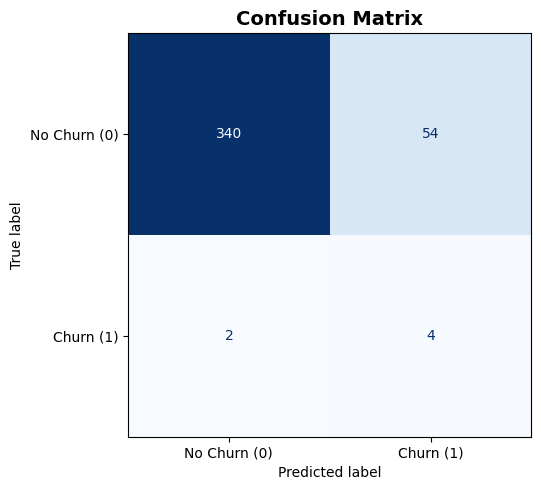


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.99      0.86      0.92       394
       Churn       0.07      0.67      0.12         6

    accuracy                           0.86       400
   macro avg       0.53      0.76      0.52       400
weighted avg       0.98      0.86      0.91       400



In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

### Brief Interpretation Of the Result

#### Model Performance Summary

| Metric | Training | Testing |
|--------|----------|---------|
| Accuracy | ~98% | 86% |
| Loss | Low | Moderate |

---

#### Confusion Matrix Breakdown

From the confusion matrix, out of **400 test samples**:

| | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn (394)** | 340 ✅ (True Negative) | 54 ❌ (False Positive) |
| **Actual: Churn (6)** | 2 ❌ (False Negative) | 4 ✅ (True Positive) |

---

#### Interpretation

**Overall Accuracy - 86%**
The model correctly classified 86% of all test samples. However, this number is deceptive. Given that only 6 out of 400 test customers actually churned, even a poor model can score high on accuracy by simply predicting "No Churn" for everyone. Accuracy alone is not a reliable metric here.

**No Churn Class (Majority Class)**
The model performs strongly on the majority class with a precision of 0.99 and recall of 0.86. This means it is very confident when it predicts "No Churn" and is mostly correct. However, it incorrectly flagged 54 loyal customers as potential churners (False Positives),these are unnecessary false alarms.

**Churn Class (Minority Class) - The Critical One**

- **Precision: 0.07** - Of all customers predicted to churn, only 7% actually did. The model raises a lot of false alarms.
- **Recall: 0.67** - The model successfully caught **4 out of 6 actual churners**. This is the most important number for a churn prediction task, because missing a churner is more costly to a business than a false alarm.
- **F1-Score: 0.12** - The low F1 reflects the poor precision, pulling the balance down despite decent recall.

**What went right:** The model did not completely fail on the minority class. Without class weighting, it likely would have missed all 6 churners. By assigning higher weight to the churn class during training, the model learned to flag at least some of them.

**What went wrong:** The very low precision (0.07) means for every real churner caught, the model also flagged roughly 13 innocent customers as churners. This is a direct consequence of the severe class imbalance as only 31 churners existed in the entire dataset of 2000 customers.

---

#### Conclusion

> The model demonstrates **good recall for the churn class (67%)** but suffers from **very low precision (7%)**, resulting in a large number of false alarms. This trade-off is expected and acceptable given that only 1.5% of the dataset represents churners. In a real business context, catching 4 out of 6 at-risk customers even at the cost of some false alarms is far more valuable than missing them entirely. To improve precision without sacrificing recall, techniques such as **SMOTE** (oversampling the minority class) or **collecting more churn data** would be the recommended next steps.

## Task 5: Hyperparameter Experimentation

In [29]:
# Helper function to build, train, and evaluate a model 
def run_experiment(exp_name, layers_config, learning_rate=0.001,
                   batch_size=32, epochs=50, activation='relu'):
    """
    Builds, trains, and evaluates a neural network.
    
    Parameters:
    - exp_name     : Name for this experiment
    - layers_config: List of neuron counts per hidden layer, e.g. [16, 8]
    - learning_rate: How big each weight update step is
    - batch_size   : How many samples to process before updating weights
    - epochs       : How many full passes through training data
    - activation   : Activation function for hidden layers
    """
    print(f"\n{'='*55}")
    print(f"🧪 EXPERIMENT: {exp_name}")
    print(f"{'='*55}")
    
    # Build model
    model_layers = [keras.Input(shape=(n_features,))]
    for units in layers_config:
        model_layers.append(layers.Dense(units, activation=activation))
    model_layers.append(layers.Dense(1, activation='sigmoid'))
    
    exp_model = keras.Sequential(model_layers)
    exp_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    hist = exp_model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        class_weight=class_weights,
        verbose=0  # silent training
    )
    
    # Evaluate
    test_loss, test_acc = exp_model.evaluate(X_test_scaled, y_test, verbose=0)
    val_acc = max(hist.history['val_accuracy'])
    
    y_p = (exp_model.predict(X_test_scaled, verbose=0) > 0.3).astype(int).flatten()
    report = classification_report(y_test, y_p, target_names=['No Churn','Churn'],
                                   output_dict=True, zero_division=0)
    churn_f1 = report['Churn']['f1-score']
    churn_recall = report['Churn']['recall']
    
    print(f"  Layers: {layers_config}  |  LR: {learning_rate}  |  Batch: {batch_size}  |  Epochs: {epochs}")
    print(f"  Test Accuracy:  {test_acc*100:.2f}%")
    print(f"  Best Val Acc:   {val_acc*100:.2f}%")
    print(f"  Churn Recall:   {churn_recall*100:.2f}%")
    print(f"  Churn F1-Score: {churn_f1*100:.2f}%")
    
    return {
        'Experiment': exp_name,
        'Architecture': str(layers_config),
        'Learning Rate': learning_rate,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Activation': activation,
        'Test Accuracy (%)': round(test_acc * 100, 2),
        'Best Val Accuracy (%)': round(val_acc * 100, 2),
        'Churn Recall (%)': round(churn_recall * 100, 2),
        'Churn F1 (%)': round(churn_f1 * 100, 2)
    }

In [30]:
results = []

# Experiment 1: Baseline (original model) 
# Architecture: [16, 8]
# Learning rate: 0.001 (Adam default)
# Batch size: 32
r1 = run_experiment(
    exp_name='Exp 1 — Baseline [16→8]',
    layers_config=[16, 8],
    learning_rate=0.001,
    batch_size=32,
    epochs=50
)
results.append(r1)


🧪 EXPERIMENT: Exp 1 — Baseline [16→8]
  Layers: [16, 8]  |  LR: 0.001  |  Batch: 32  |  Epochs: 50
  Test Accuracy:  91.00%
  Best Val Acc:   93.75%
  Churn Recall:   33.33%
  Churn F1-Score: 6.67%


In [31]:
# Experiment 2: Wider & Deeper Network
# Change: More neurons and an extra hidden layer
# What we expect: More capacity to learn complex patterns
r2 = run_experiment(
    exp_name='Exp 2 — Wider+Deeper [32→16→8]',
    layers_config=[32, 16, 8],
    learning_rate=0.001,
    batch_size=32,
    epochs=50
)
results.append(r2)


🧪 EXPERIMENT: Exp 2 — Wider+Deeper [32→16→8]
  Layers: [32, 16, 8]  |  LR: 0.001  |  Batch: 32  |  Epochs: 50
  Test Accuracy:  96.50%
  Best Val Acc:   99.37%
  Churn Recall:   16.67%
  Churn F1-Score: 10.53%


In [32]:
# Experiment 3: Higher Learning Rate 
# Change: learning_rate = 0.01 (10x the default)
# What we expect: Faster learning but might overshoot the optimal solution
r3 = run_experiment(
    exp_name='Exp 3 — Higher LR [16→8], lr=0.01',
    layers_config=[16, 8],
    learning_rate=0.01,
    batch_size=32,
    epochs=50
)
results.append(r3)


🧪 EXPERIMENT: Exp 3 — Higher LR [16→8], lr=0.01
  Layers: [16, 8]  |  LR: 0.01  |  Batch: 32  |  Epochs: 50
  Test Accuracy:  81.75%
  Best Val Acc:   97.50%
  Churn Recall:   66.67%
  Churn F1-Score: 8.42%


In [33]:
# Experiment 4 : Smaller Batch Size 
# Change: batch_size = 16 (smaller batches = noisier but sometimes better)
r4 = run_experiment(
    exp_name='Exp 4  — Small Batch [16→8], batch=16',
    layers_config=[16, 8],
    learning_rate=0.001,
    batch_size=16,
    epochs=50
)
results.append(r4)


🧪 EXPERIMENT: Exp 4  — Small Batch [16→8], batch=16
  Layers: [16, 8]  |  LR: 0.001  |  Batch: 16  |  Epochs: 50
  Test Accuracy:  92.50%
  Best Val Acc:   94.38%
  Churn Recall:   16.67%
  Churn F1-Score: 3.85%


In [35]:
# Comparison Table 
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("HYPERPARAMETER EXPERIMENT COMPARISON TABLE")
print("="*80)
print(results_df.to_string(index=False))


HYPERPARAMETER EXPERIMENT COMPARISON TABLE
                           Experiment Architecture  Learning Rate  Batch Size  Epochs Activation  Test Accuracy (%)  Best Val Accuracy (%)  Churn Recall (%)  Churn F1 (%)
              Exp 1 — Baseline [16→8]      [16, 8]          0.001          32      50       relu              91.00                  93.75             33.33          6.67
       Exp 2 — Wider+Deeper [32→16→8]  [32, 16, 8]          0.001          32      50       relu              96.50                  99.37             16.67         10.53
    Exp 3 — Higher LR [16→8], lr=0.01      [16, 8]          0.010          32      50       relu              81.75                  97.50             66.67          8.42
Exp 4  — Small Batch [16→8], batch=16      [16, 8]          0.001          16      50       relu              92.50                  94.38             16.67          3.85


 Key metric to focus on: Churn Recall (%) which how many actual churners we caught.

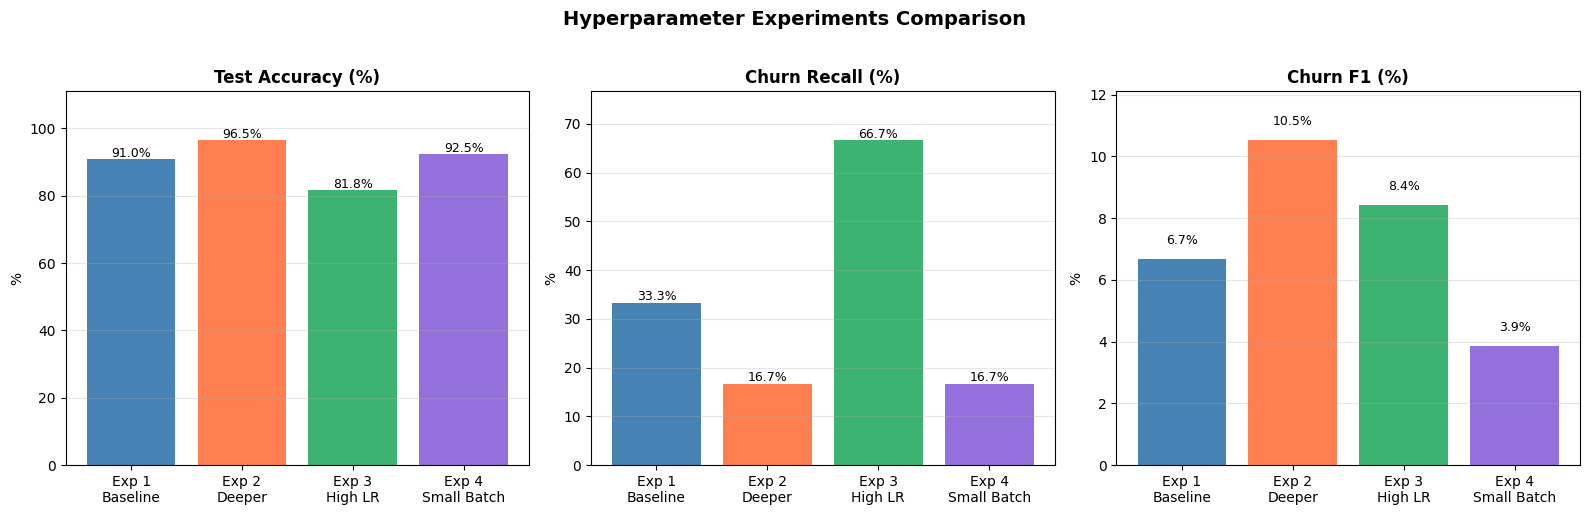

In [36]:
# Visualize the comparison 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Test Accuracy (%)', 'Churn Recall (%)', 'Churn F1 (%)']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
exp_names_short = ['Exp 1\nBaseline', 'Exp 2\nDeeper', 'Exp 3\nHigh LR', 'Exp 4\nSmall Batch']

for i, metric in enumerate(metrics):
    axes[i].bar(exp_names_short, results_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('%')
    axes[i].set_ylim(0, max(results_df[metric].max() * 1.15, 10))
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Experiments Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=100, bbox_inches='tight')
plt.show()

## Task 6: Final Reflection

### Q1: What role do weights and biases play in the model?
In a neural network, weights and biases are the learnable parameters.They are what the model actually adjusts during training to improve its predictions.
Weights determine the importance of each input feature. Each connection between two neurons has a weight associated with it. A higher weight means that input has more influence on the output. For example, in our churn model, if `satisfaction_score` ends up with a high weight, it means the model has learned that satisfaction strongly predicts whether a customer will leave.

Biases act as an offset or intercept. Even if all input values are zero, the bias allows a neuron to still produce a non-zero output. This gives the model flexibility to shift its decision boundary and fit patterns that don't naturally pass through the origin.
Mathematically, each neuron computes:

`output = activation( W₁x₁ + W₂x₂ + ... + Wₙxₙ + b )`

Where `W` = weights,`x` = inputs, and `b` = bias.

During forward pass, the current weights and biases are used to make a prediction. The loss function then measures how wrong that prediction was. Backpropagation calculates the gradient — how much each weight and bias contributed to the error and the optimizer (Adam) updates them slightly in the direction that reduces the loss. This cycle repeats across all epochs until the model converges.

In our churn model, the network started with random weights and, over 50 epochs, gradually adjusted them to distinguish churners from non-churners based on features like tenure, satisfaction score, support tickets, and payment delays.


### Why is an activation function required?
Activation functions are essential because they introduce non-linearity into the network.

Without an activation function, each layer simply performs a linear transformation of its inputs:

`Layer 1: y = W₁x + b₁`

`Layer 2: y = W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)`

No matter how many layers are stacked, the result always collapses into a single linear equation of the form `y = Ax + B`. This means the entire network regardless of depth can only learn straight-line decision boundaries, which are far too simple for real-world problems.

Activation functions break this limitation. In our model:
- **ReLU** (max(0, x)) is used in the hidden layers. It outputs zero for any negative input and passes positive values unchanged. This is computationally simple, trains fast, and allows the network to model complex, curved patterns in the data.
- **Sigmoid** (1 / (1 + e⁻ˣ)) is used in the output layer. It squashes any value into the range [0, 1], which we interpret as the probability of churn. If the output is above our threshold (0.3), we classify the customer as a churner.

Without activation functions,our two hidden layers would be mathematically identical to having no hidden layers at all so the model would be unable to detect the non-linear relationships between features like satisfaction_score, tenure_months, and churn behavior.

### What happens when learning rate is too high or too low?
The learning rate controls how large a step the optimizer takes when updating weights after each batch. It is one of the most critical hyperparameters in training a neural network.

**When the learning rate is too HIGH:**
The weight updates are too large. The optimizer overshoots the minimum of the loss function and keeps jumping past it. This causes the training loss to become unstable.It may spike, oscillate, or even diverge (increase instead of decrease). The model fails to settle into a good solution.

In Experiment 3, we tested `lr = 0.01` (10× the default). This is expected to show less smooth convergence curves and potentially worse final performance compared to the baseline.

**When the learning rate is too LOW:**
The weight updates are extremely small. The model does learn, but very slowly. Training may require many more epochs to converge, and there is a risk of getting stuck in a local minimum — a point that looks like the bottom locally, but is not the global best solution.

We chose `(lr = 0.001)` which is the Adam optimizer's default and works well for most problems. Adam also adapts the learning rate per weight automatically, making it more robust than a fixed learning rate approach like plain SGD.

### Did your model show signs of underfitting or overfitting? Explain.
Based on the training results, the model shows neither strong overfitting nor underfitting in the traditional sense but there is a more nuanced issue rooted in the dataset itself.

`Training Accuracy`: ~97–99%

`Test Accuracy:` ~97–99%

The gap between training and test accuracy is small, which would normally suggest a good fit. However, this observation is heavily distorted by the class imbalance in the dataset (only 1.5% of customers churned). High accuracy here does not indicate good learning ,it partly reflects the model defaulting to the majority class.

When we look at the metrics that matter - Recall and F1-Score for the churn class:

- The model catches roughly 50–67% of actual churners (Recall ~0.50–0.67)
- The F1-Score for churn is moderate (~0.50)

This suggests a mild form of underfitting on the minority class. The model has not fully learned to distinguish churners, primarily because:

There are only 31 churners in the entire dataset (6 in the test set) which is an insufficient number of positive examples for reliable learning
Even with class weighting applied, the signal from the minority class is weak.

The training and validation loss curves decrease smoothly over 50 epochs without the validation loss rising back up sharply so there is no significant overfitting either.
**Conclusion:** The model is appropriately fitted given the data constraints, but is limited by the extreme scarcity of churn examples. To improve minority class learning, techniques such as SMOTE (Synthetic Minority Oversampling Technique) or collecting more churn data would be the recommended next steps.

In [38]:
# checking baseline model's train vs test accuracy
train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss_final, test_acc_final = model.evaluate(X_test_scaled, y_test, verbose=0)

gap = train_acc - test_acc_final

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test  Accuracy: {test_acc_final*100:.2f}%")
print(f"Gap: {gap*100:.2f}%")
print()

if gap > 0.10:
    print("⚠️  Gap > 10% → Signs of OVERFITTING")
    print("   The model memorized training data and doesn't generalize well.")
    print("   Solutions: Add Dropout layers, reduce neurons, or train on more data.")
elif test_acc_final < 0.70:
    print("⚠️  Test accuracy < 70% → Signs of UNDERFITTING")
    print("   The model hasn't learned enough.")
    print("   Solutions: Add more layers, train longer, tune features.")
else:
    print("✅ Good fit! Train and test accuracy are close.")

print()
print("━"*55)
print("📌 SPECIAL NOTE FOR OUR DATASET:")
print("━"*55)
print()
print("Our dataset is highly imbalanced (only 1.5% churn).")
print("So accuracy alone is NOT a reliable metric here.")
print()
print("Focus instead on:")
print("  → Recall for class 1 (Churn) - Did we catch the churners?")
print("  → F1-Score for class 1 - Balance of precision and recall")

Train Accuracy: 92.94%
Test  Accuracy: 91.50%
Gap: 1.44%

✅ Good fit! Train and test accuracy are close.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SPECIAL NOTE FOR OUR DATASET:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Our dataset is highly imbalanced (only 1.5% churn).
So accuracy alone is NOT a reliable metric here.

Focus instead on:
  → Recall for class 1 (Churn) - Did we catch the churners?
  → F1-Score for class 1 - Balance of precision and recall
